
--- Distribuição Treino (Target: Endividamento) ---
Vulnerable
0    73.76%
1    26.24%
Name: proportion, dtype: str

TREINANDO E AVALIANDO: XGBoost

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.74      0.69      0.71      2934
           1       0.26      0.32      0.29      1044

    accuracy                           0.59      3978
   macro avg       0.50      0.50      0.50      3978
weighted avg       0.61      0.59      0.60      3978



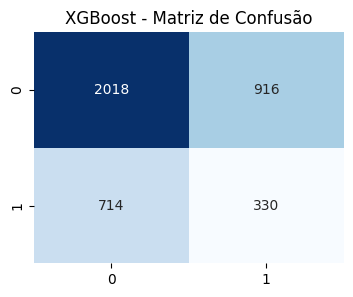


TREINANDO E AVALIANDO: Random Forest

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      2934
           1       0.33      0.01      0.01      1044

    accuracy                           0.74      3978
   macro avg       0.54      0.50      0.43      3978
weighted avg       0.63      0.74      0.63      3978



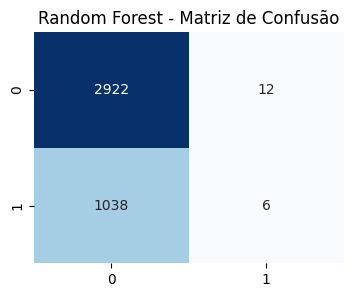


TREINANDO E AVALIANDO: Regressão Logística

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.74      0.50      0.60      2934
           1       0.27      0.51      0.35      1044

    accuracy                           0.50      3978
   macro avg       0.51      0.51      0.47      3978
weighted avg       0.62      0.50      0.53      3978



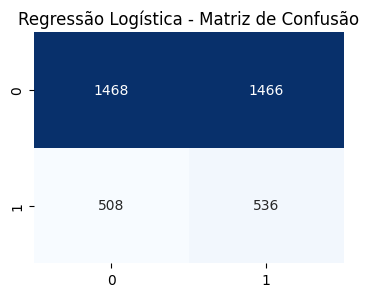

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
df = df[df['Desired_Savings'] > 0].copy()



df['Vulnerable'] = (df['Loan_Repayment'] / df['Income'] >= 0.10).astype(int)


ratio_cols = [
    'Rent', 'Healthcare', 'Education', 'Groceries', 'Transport', 
    'Utilities', 'Insurance', 'Eating_Out', 'Entertainment', 'Miscellaneous'
]
for col in ratio_cols:
    df[f'{col}_Ratio'] = df[col] / df['Income']

features = ['Age', 'Dependents'] + [f'{col}_Ratio' for col in ratio_cols]
X = df[features]
y = df['Vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print(f"\n--- Distribuição Treino (Target: Endividamento) ---")
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

X_train_final = X_train[['Age', 'Dependents']].copy()
X_test_final = X_test[['Age', 'Dependents']].copy()

for col in [f'{c}_Ratio' for c in ratio_cols]:

    bins = pd.qcut(X_train[col], q=4, retbins=True, duplicates='drop')[1]
    

    col_train = pd.cut(X_train[col], bins=bins, labels=['Q1', 'Q2', 'Q3', 'Q4'], include_lowest=True)
    col_test = pd.cut(X_test[col], bins=bins, labels=['Q1', 'Q2', 'Q3', 'Q4'], include_lowest=True)
    

    dummies_train = pd.get_dummies(col_train, prefix=col)
    dummies_test = pd.get_dummies(col_test, prefix=col)
    

    dummies_test = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)
    
    X_train_final = pd.concat([X_train_final, dummies_train], axis=1)
    X_test_final = pd.concat([X_test_final, dummies_test], axis=1)


peso_balanceamento = (y_train == 0).sum() / (y_train == 1).sum()

modelos = {
    "XGBoost": xgb.XGBClassifier(scale_pos_weight=peso_balanceamento, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000))
}

for nome, modelo in modelos.items():
    print(f"\n" + "="*50)
    print(f"TREINANDO E AVALIANDO: {nome}")
    print("="*50)
    
    modelo.fit(X_train_final, y_train)
    y_pred = modelo.predict(X_test_final)
    
    print("\n--- Relatório de Classificação ---")
    print(classification_report(y_test, y_pred))
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{nome} - Matriz de Confusão')
    plt.show()